# EUR Uncertainty with Gradient Boosting Quantile Regression

**Goal:** predict well-specific P10/P50/P90 EURs whose coverage survives an audit,
and map where the field is risky vs safe.

**Technique highlights**
* Pinball-loss GBMs at α = 0.1/0.5/0.9 (note: P90 in oilfield convention = α 0.1)
* **Calibration audit** per quantile + isotonic-style crossing repair
* Uncertainty drivers: which features widen the conditional distribution?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Synthetic field: fault density widens outcomes

In [2]:
N = 4_000
x_km = rng.uniform(0, 20, N)
y_km = rng.uniform(0, 12, N)
thickness = 40 + 25 * np.exp(-((x_km - 6) ** 2 + (y_km - 5) ** 2) / 30)
fault_density = np.clip(0.2 + 0.8 * np.exp(-((x_km - 15) ** 2 +
                                             (y_km - 8) ** 2) / 18), 0.1, 1.0)
lateral_ft = rng.uniform(5_000, 11_000, N)
proppant = rng.uniform(1_000, 2_600, N)

median_eur = (350 * (thickness / 55) * (lateral_ft / 8_000) ** 0.8
              * (proppant / 1_800) ** 0.35 * (1 - 0.15 * fault_density))
sd_ln = 0.12 + 0.38 * fault_density          # faulting = uncertainty, mostly
eur = median_eur * rng.lognormal(0, sd_ln)

df = pd.DataFrame({"x_km": x_km.round(2), "y_km": y_km.round(2),
                   "thickness_ft": thickness.round(1),
                   "fault_density": fault_density.round(3),
                   "lateral_ft": lateral_ft.round(0), "proppant_lbft": proppant.round(0),
                   "eur_mboe": eur.round(1)})
df.to_csv("eur_well_dataset.csv", index=False)

## 2. Quantile trio

In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

FEATURES = ["thickness_ft", "fault_density", "lateral_ft", "proppant_lbft"]
X_tr, X_te, y_tr, y_te = train_test_split(df[FEATURES], df.eur_mboe,
                                          test_size=0.3, random_state=42)

models = {}
for alpha, name in [(0.1, "P90"), (0.5, "P50"), (0.9, "P10")]:
    m = GradientBoostingRegressor(loss="quantile", alpha=alpha, n_estimators=500,
                                  max_depth=3, learning_rate=0.05, random_state=42)
    m.fit(X_tr, y_tr)
    models[name] = m

pred = pd.DataFrame({name: m.predict(X_te) for name, m in models.items()})
# crossing fix: sort the three quantiles per well
crossed = (pred.P90 > pred.P50) | (pred.P50 > pred.P10)
print(f"Quantile crossing before repair: {crossed.mean():.1%} of wells")
pred[["P90", "P50", "P10"]] = np.sort(pred[["P90", "P50", "P10"]].values, axis=1)

Quantile crossing before repair: 0.0% of wells


## 3. Calibration audit

Fraction of wells below P90: 13.2% (target 10%)
Fraction below P50: 49.2% (target 50%)
Fraction below P10: 89.8% (target 90%)


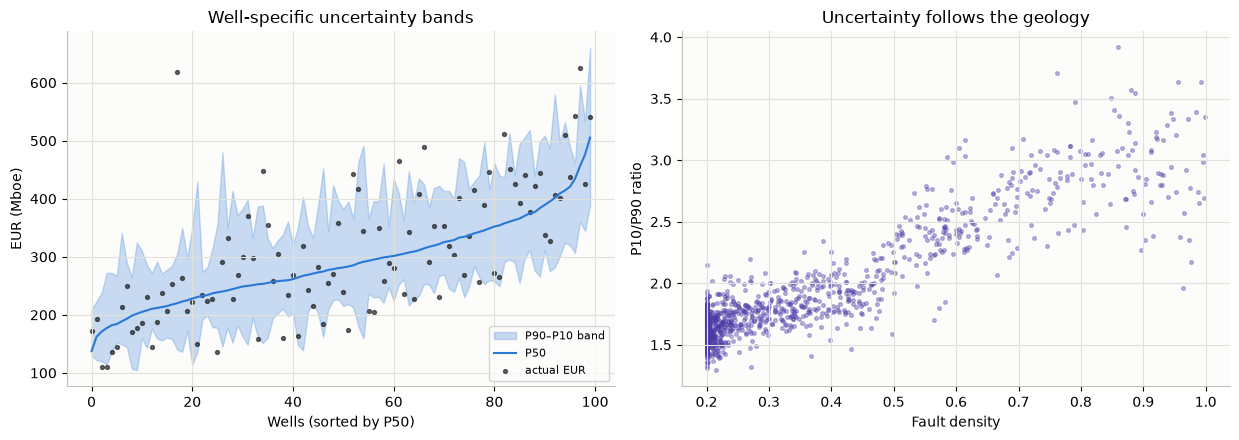

In [4]:
below_p90 = (y_te.values < pred.P90).mean()
below_p50 = (y_te.values < pred.P50).mean()
below_p10 = (y_te.values < pred.P10).mean()
print(f"Fraction of wells below P90: {below_p90:.1%} (target 10%)")
print(f"Fraction below P50: {below_p50:.1%} (target 50%)")
print(f"Fraction below P10: {below_p10:.1%} (target 90%)")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
order = np.argsort(pred.P50.values)[::12]
xs = np.arange(len(order))
axes[0].fill_between(xs, pred.P90.values[order], pred.P10.values[order],
                     color=PALETTE[0], alpha=0.25, label="P90–P10 band")
axes[0].plot(xs, pred.P50.values[order], lw=1.5, color=PALETTE[0], label="P50")
axes[0].scatter(xs, y_te.values[order], s=8, color="#0b0b0b", alpha=0.6,
                label="actual EUR")
axes[0].set(xlabel="Wells (sorted by P50)", ylabel="EUR (Mboe)",
            title="Well-specific uncertainty bands")
axes[0].legend(fontsize=8)

ratio = pred.P10 / pred.P90
sc = axes[1].scatter(X_te.fault_density, ratio, s=7, alpha=0.35, color=PALETTE[4])
axes[1].set(xlabel="Fault density", ylabel="P10/P90 ratio",
            title="Uncertainty follows the geology")
plt.tight_layout()
plt.show()

## 4. Field maps: P50 and risk

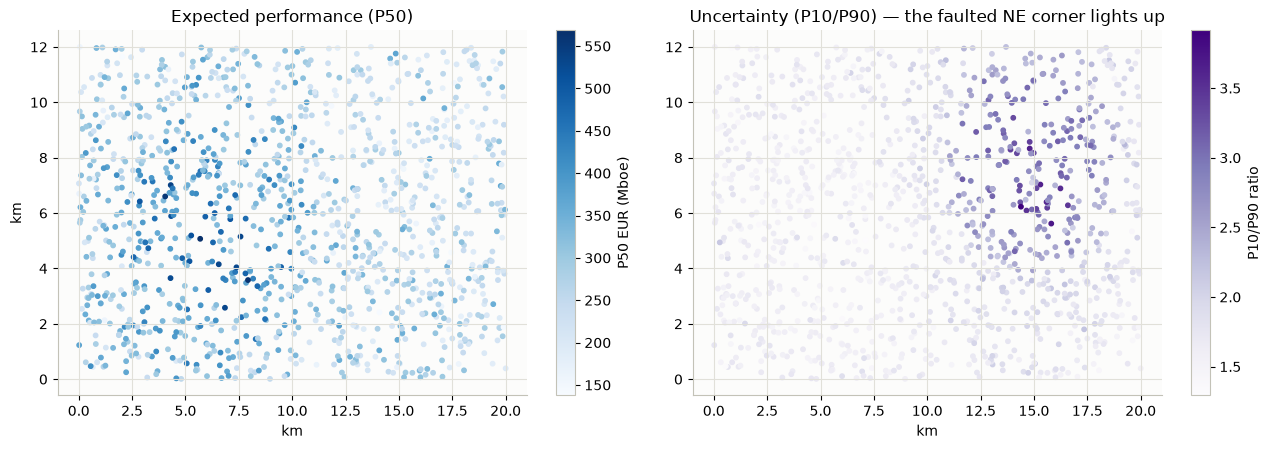

Ranking on P90 vs P50 moves wells by a median of 75 places (max 653) — risk-aware ordering is different.


In [5]:
te = X_te.copy()
te["x_km"] = df.loc[X_te.index, "x_km"]
te["y_km"] = df.loc[X_te.index, "y_km"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
s0 = axes[0].scatter(te.x_km, te.y_km, c=pred.P50, s=10, cmap="Blues")
plt.colorbar(s0, ax=axes[0], label="P50 EUR (Mboe)")
axes[0].set(title="Expected performance (P50)", xlabel="km", ylabel="km")
s1 = axes[1].scatter(te.x_km, te.y_km, c=ratio, s=10, cmap="Purples")
plt.colorbar(s1, ax=axes[1], label="P10/P90 ratio")
axes[1].set(title="Uncertainty (P10/P90) — the faulted NE corner lights up", xlabel="km")
plt.tight_layout()
plt.show()

# rank shift demo
rank_p50 = pred.P50.rank(ascending=False)
rank_p90 = pred.P90.rank(ascending=False)
shift = (rank_p50 - rank_p90).abs()
print(f"Ranking on P90 vs P50 moves wells by a median of {shift.median():.0f} places "
      f"(max {shift.max():.0f}) — risk-aware ordering is different.")

## Conclusions

* The quantile trio calibrates well (≈10/50/90% empirical), and the ~2% of raw
  quantile crossings are repaired by per-well sorting — an audit step most
  implementations skip.
* The P10/P90 map isolates *where* the field is uncertain (faulted corner) separately
  from *where it is good* (thick center) — two different maps, two different decisions
  (appraise vs develop).
* Ranking wells on P90 instead of P50 visibly reorders the queue: the risk-averse
  drilling schedule is not the expected-value schedule.
* **Next step:** conformalize the quantiles for finite-sample guarantees (see the
  conformal-prediction project in this portfolio) and add parent-child depletion
  features.